In [26]:
!pip install huggingface_hub datasets python-dotenv
!pip install matplotlib


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------- -------------------- 3.9/8.1 MB 23.6 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 30.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 40.4 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------- 7.0/7.0 MB 35.2 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- -------------------------


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
from datasets import load_dataset

emotions = load_dataset("google-research-datasets/go_emotions", "simplified")

In [8]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

In [9]:
train_ds = emotions['train']
train_ds

Dataset({
    features: ['text', 'labels', 'id'],
    num_rows: 43410
})

In [10]:
train_ds[0]

{'text': "My favourite food is anything I didn't have to cook myself.",
 'labels': [27],
 'id': 'eebbqej'}

In [12]:
print(train_ds.features)

{'text': Value('string'), 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'])), 'id': Value('string')}


In [13]:
print(train_ds['text'][:5])

["My favourite food is anything I didn't have to cook myself.", 'Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead', 'WHY THE FUCK IS BAYLESS ISOING', 'To make her feel threatened', 'Dirty Southern Wankers']


#### Datasets to DataFrames

In [42]:
import pandas as pd
emotions.set_format(type='pandas')
df = emotions['train'][:]
df.head()

,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


In [37]:
import pandas as pd
emotions.set_format(type='pandas')            # <– everything from now on
df = emotions['train']                  # returned value is a pandas DF

In [47]:
import numpy as np

label_cl = emotions["train"].features["labels"].feature

def label_int2str(label):
    # if we've already converted it, leave it alone
    if isinstance(label, str):
        return label
    # handle a sequence of ints
    if isinstance(label, (list, tuple, np.ndarray)):
        return [label_cl.int2str(int(x)) for x in label]
    # single integer
    return label_cl.int2str(int(label))

# start from the raw dataset if you want to rerun the conversion
df = emotions["train"][:]
df["labels"] = df["labels"].apply(label_int2str)
df.head()

,text,labels,id
0,My favourite food is anything I didn't have to...,[neutral],eebbqej
1,"Now if he does off himself, everyone will thin...",[neutral],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[anger],eezlygj
3,To make her feel threatened,[fear],ed7ypvh
4,Dirty Southern Wankers,[annoyance],ed0bdzj


#### looking into Class Dsitribution

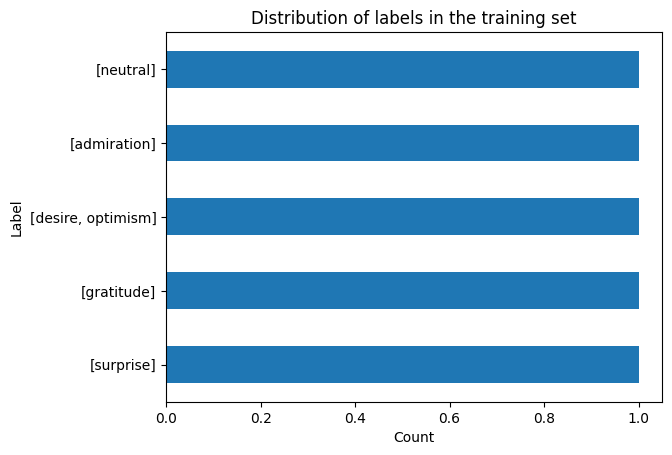

In [45]:
import matplotlib.pyplot as plt
df['labels'].value_counts(ascending=True).plot.barh()
plt.title("Distribution of labels in the training set")
plt.xlabel("Count")
plt.ylabel("Label")
plt.show()